In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shwetabh123/mall-customers")

100%|██████████| 1.56k/1.56k [00:00<00:00, 906kB/s]

Extracting files...


In [ ]:
import os

file_path = os.path.join(path, 'Mall_Customers.csv')
data = pd.read_csv(file_path)
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
data.describe(include=['object'])

,Genre
count,200
unique,2
top,Female
freq,112


In [ ]:
data = data.drop(['CustomerID', 'Genre', 'Age'], axis=1)

In [ ]:
data.columns = ['AnnualIncome', 'SpendingScore']
print(data.head())

   AnnualIncome  SpendingScore
0            15             39
1            15             81
2            16              6
3            16             77
4            17             40


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['AnnualIncome', 'SpendingScore']])

In [ ]:
wcss = []

In [ ]:
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

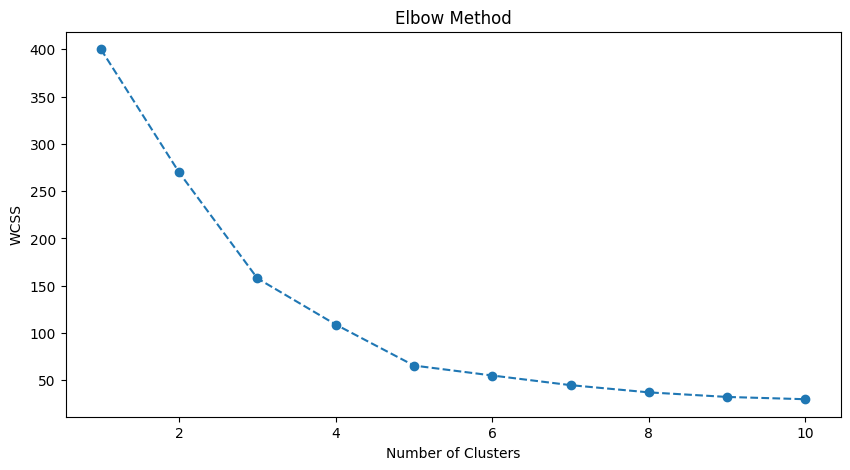

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

100%|██████████| 1.56k/1.56k [00:00<00:00, 748kB/s]

Extracting files...


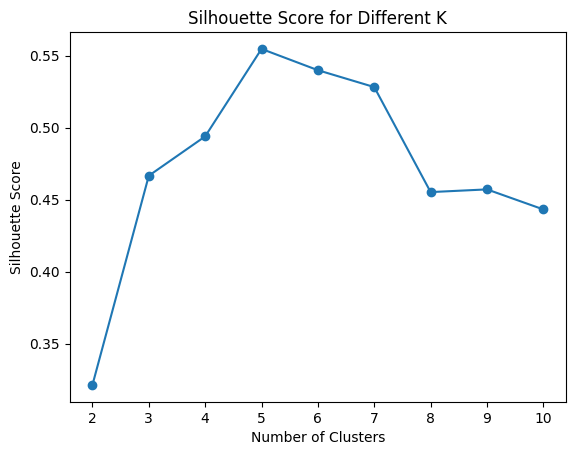

In [4]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Data download and loading
path = kagglehub.dataset_download("shwetabh123/mall-customers")
file_path = os.path.join(path, 'Mall_Customers.csv')
data = pd.read_csv(file_path)

# Data preprocessing (dropping customer ID, genre, age, and renaming columns)
data = data.drop(['CustomerID', 'Genre', 'Age'], axis=1)
data.columns = ['AnnualIncome', 'SpendingScore']

silhouette_scores = []

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['AnnualIncome', 'SpendingScore']])

for i in range(2, 11):
    kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
print(kmeans.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [ ]:
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print(original_centroids)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


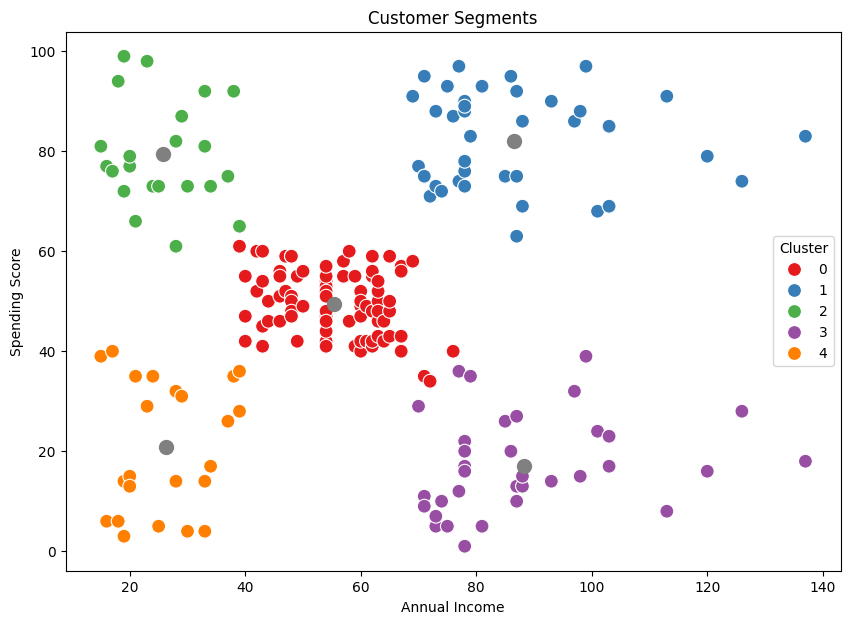

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data['AnnualIncome'], y=data['SpendingScore'], hue=data['Cluster'], palette='Set1', s=100)
plt.scatter(original_centroids[:, 0], original_centroids[:, 1], s=100, c='grey', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [ ]:
cluster_analysis = data.groupby('Cluster').mean()
print(cluster_analysis)

         AnnualIncome  SpendingScore
Cluster                             
0           55.296296      49.518519
1           86.538462      82.128205
2           25.727273      79.363636
3           88.200000      17.114286
4           26.304348      20.913043


In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print("\nNumber of customers in each cluster:")
print(data['Cluster'].value_counts())


Number of customers in each cluster:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [ ]:
new_customer = np.array([[50, 70]])

In [21]:
new_customer = np.array([[50, 70]])
predicted_cluster = kmeans.predict(new_customer)
print(f"The new customer belongs to cluster: {predicted_cluster[0]}")

The new customer belongs to cluster: 1


In [ ]:
sil_score = silhouette_score(scaled_features, data['Cluster'])
db_score = davies_bouldin_score(scaled_features, data['Cluster'])
ch_score = calinski_harabasz_score(scaled_features, data['Cluster'])

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Score: 248.64932001536357
